# Etapa 1 — EDA + ML Canvas + Baselines

**Tech Challenge Fase 01** — Previsão de Churn em Telecomunicações

## Objetivo
Explorar o dataset Telco Customer Churn, entender a distribuição dos dados,
identificar padrões e treinar modelos baseline para comparação com a MLP.

## ML Canvas

| Dimensão | Descrição |
|---|---|
| **Stakeholders** | Diretoria de Retenção, Time de Marketing, Equipe de Dados |
| **Problema de Negócio** | Perda acelerada de clientes → necessidade de identificação precoce de risco de churn |
| **Métrica de Negócio** | Custo de churn evitado (redução de 15% na taxa de cancelamento = economia estimada de R$ X/mês) |
| **Métrica Técnica** | AUC-ROC ≥ 0.80, Recall ≥ 0.70, F1 ≥ 0.65 |
| **SLOs** | Latência de predição < 100ms (p95), Disponibilidade ≥ 99.5% |
| **Input Data** | Dados tabulares: demográficos, serviços contratados, pagamentos, tenure |
| **Output** | Classificação binária (Churn/No Churn) + probabilidade + nível de risco |
| **Decisão Acionável** | Campanhas de retenção direcionadas, ofertas personalizadas para clientes de alto risco |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import mlflow

# Configurações
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 6)

SEED = 42
np.random.seed(SEED)

## 1. Carregamento dos Dados

In [2]:
# Carregar dataset
df = pd.read_csv('../data/raw/telco_churn.csv')
print(f'Shape: {df.shape}')
print(f'Colunas: {df.columns.tolist()}')
df.head()

Shape: (7043, 21)
Colunas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Análise Exploratória — Volume e Qualidade

In [3]:
# Informações gerais
print('=== INFO ===')
print(df.info())
print('\n=== VALORES NULOS ===')
print(df.isnull().sum())
print('\n=== ESTATÍSTICAS DESCRITIVAS ===')
df.describe(include='all')

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nu

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [4]:
# Verificar TotalCharges (tem espaços em branco)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'NaN em TotalCharges: {df["TotalCharges"].isna().sum()}')
print(f'Registros com TotalCharges vazio são clientes com tenure=0:')
df[df['TotalCharges'].isna()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

NaN em TotalCharges: 11
Registros com TotalCharges vazio são clientes com tenure=0:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


## 3. Distribuição do Target (Churn)

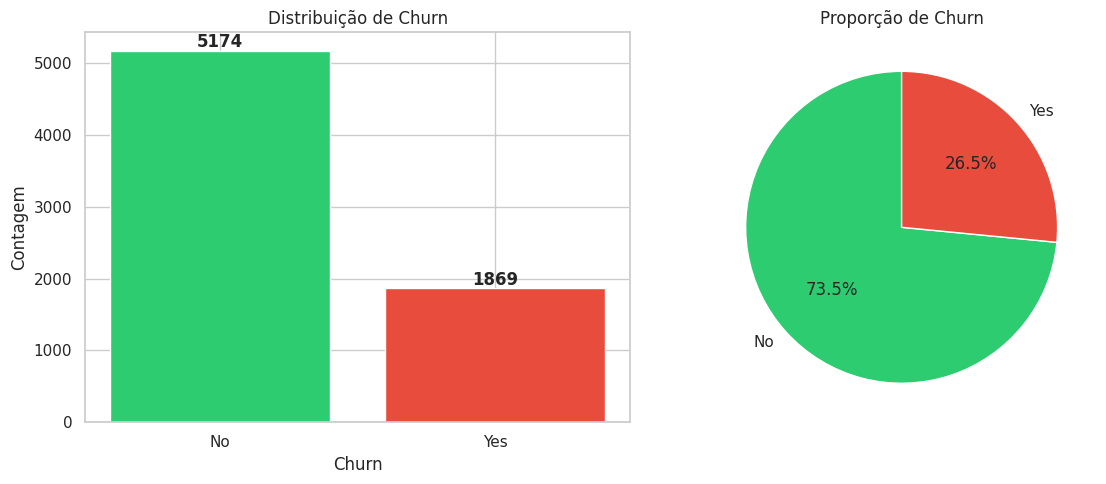


Taxa de Churn: 26.5% — Dataset desbalanceado


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Contagem
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribuição de Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Contagem')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Proporção
churn_pct = df['Churn'].value_counts(normalize=True) * 100
axes[1].pie(churn_pct.values, labels=churn_pct.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporção de Churn')

plt.tight_layout()
plt.savefig('../docs/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTaxa de Churn: {churn_pct["Yes"]:.1f}% — Dataset desbalanceado')

## 4. Análise de Features — Data Readiness

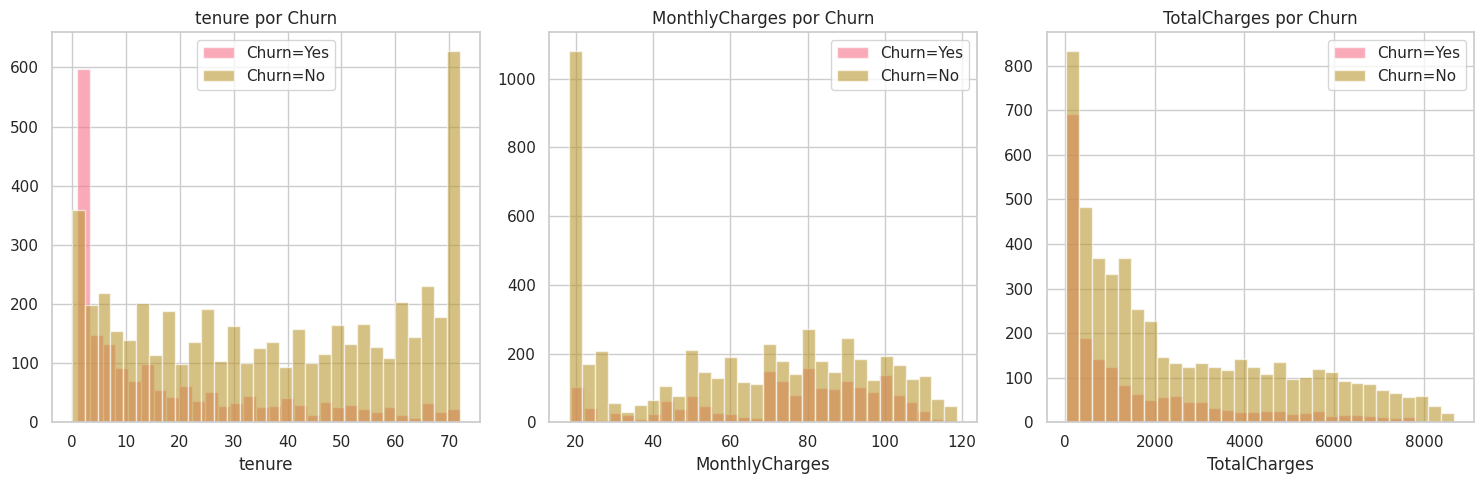

In [6]:
# Features numéricas vs Churn
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    for label in ['Yes', 'No']:
        subset = df[df['Churn'] == label][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, label=f'Churn={label}')
    ax.set_title(f'{col} por Churn')
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.savefig('../docs/numeric_features_churn.png', dpi=150, bbox_inches='tight')
plt.show()

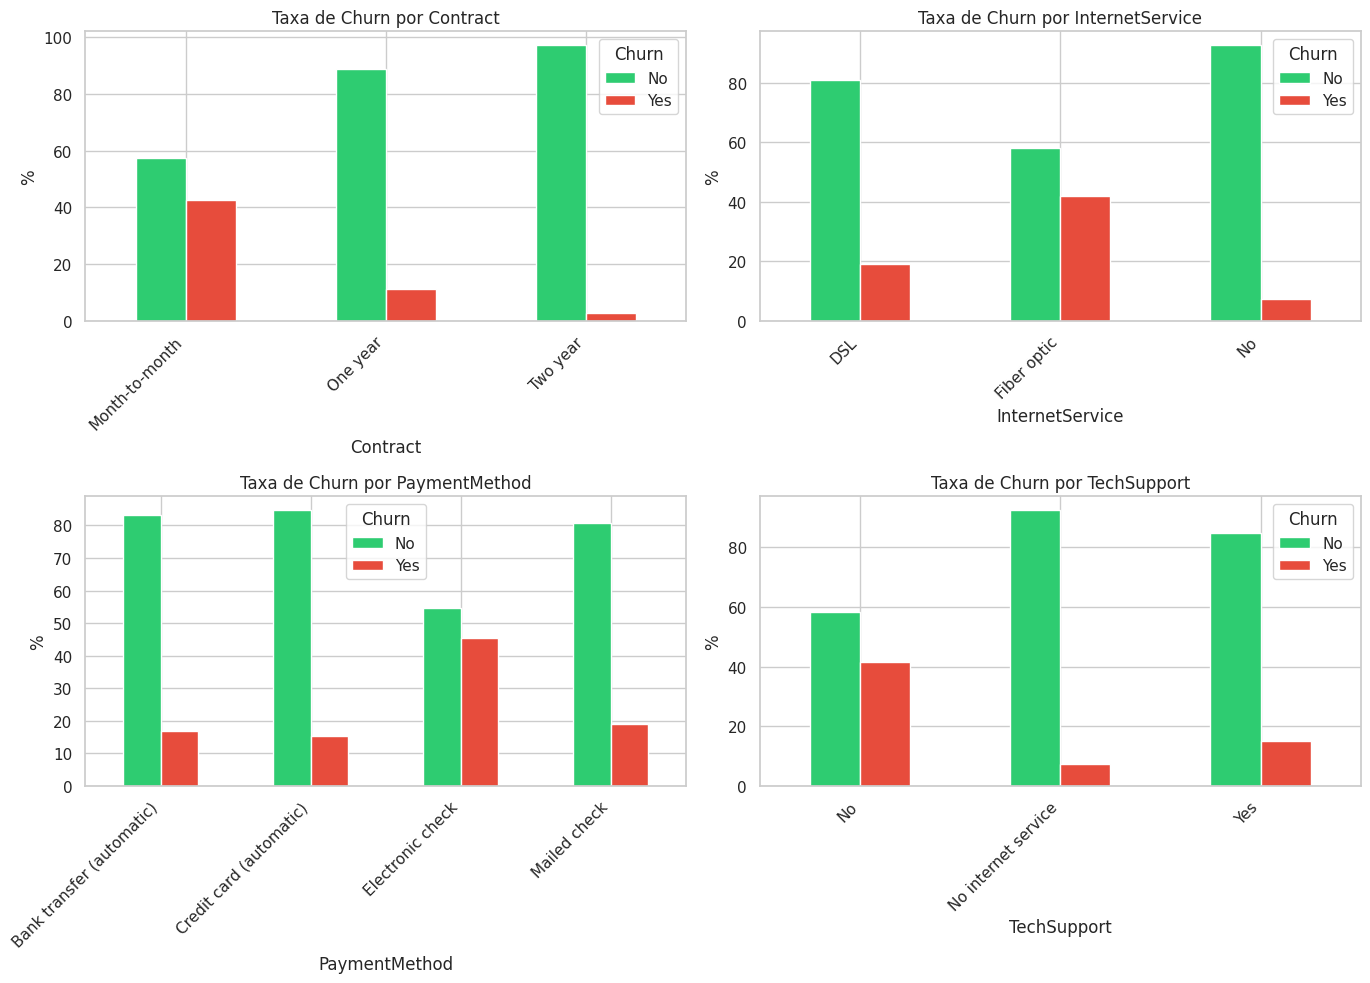

In [7]:
# Features categóricas mais relevantes vs Churn
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
    ax.set_title(f'Taxa de Churn por {col}')
    ax.set_ylabel('%')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend(title='Churn')

plt.tight_layout()
plt.savefig('../docs/categorical_features_churn.png', dpi=150, bbox_inches='tight')
plt.show()

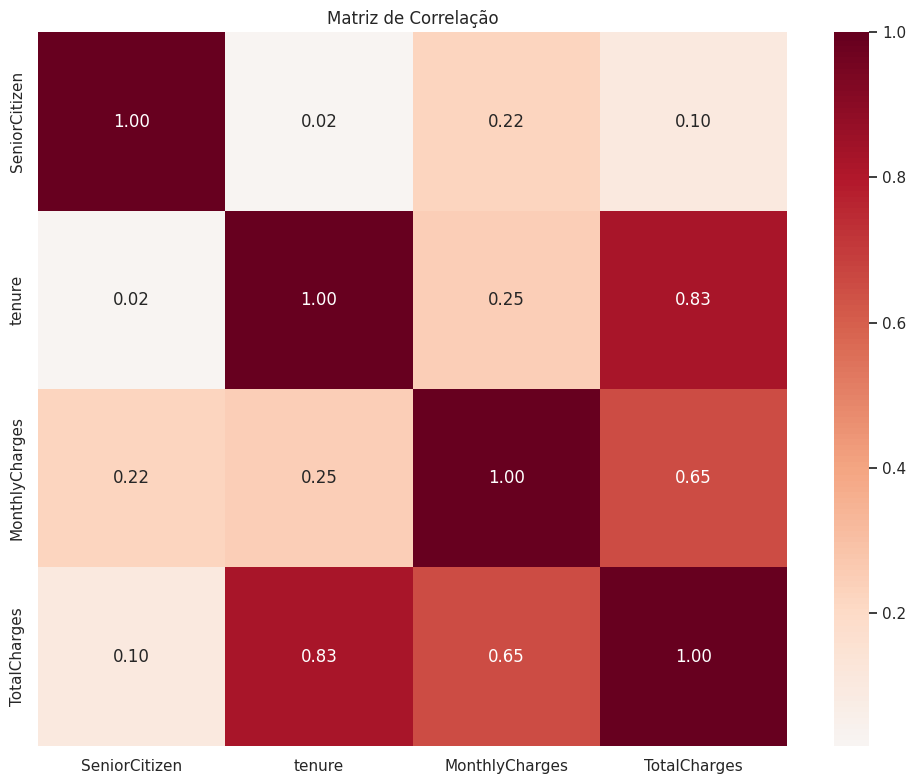

In [8]:
# Correlação entre features numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.savefig('../docs/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Preparação para Modelagem

In [9]:
from src.data.load_data import preprocess_raw_data
from src.features.pipeline import prepare_features, build_preprocessor

# Preprocessar
df_clean = preprocess_raw_data(df)
X, y = prepare_features(df_clean)

print(f'Features: {X.shape}')
print(f'Target: {y.shape}')
print(f'Churn rate: {y.mean():.2%}')

2026-05-04 15:23:55 [info     ] preprocessamento_iniciado     


2026-05-04 15:23:55 [info     ] preprocessamento_concluido     churn_rate=26.54% colunas=20 linhas=7043


2026-05-04 15:23:55 [info     ] features_preparadas            X_shape=(7043, 19) y_shape=(7043,)


Features: (7043, 19)
Target: (7043,)
Churn rate: 26.54%


## 6. Baselines com MLflow Tracking

In [10]:
from src.models.baseline import train_baselines
from src.utils.reproducibility import set_seeds

set_seeds(SEED)
mlflow.set_experiment('churn-prediction-eda')

with mlflow.start_run(run_name='eda_baselines'):
    mlflow.log_params({
        'dataset': 'telco_customer_churn',
        'dataset_version': '1.0',
        'n_samples': len(df),
        'n_features': X.shape[1],
        'churn_rate': f'{y.mean():.4f}',
    })
    
    results = train_baselines(X, y.values)

# Exibir resultados
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print('\n=== RESULTADOS DOS BASELINES ===')
results_df

2026/05/04 15:23:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/05/04 15:23:58 INFO mlflow.store.db.utils: Updating database tables


2026/05/04 15:23:59 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction-eda' does not exist. Creating a new experiment.


2026-05-04 15:23:59 [info     ] preprocessor_construido        cat_features=15 num_features=4


2026-05-04 15:23:59 [info     ] treinando_baseline             modelo=DummyClassifier


...

2026-05-04 15:24:11 [info     ] baseline_avaliado              accuracy=0.7873065455061763 f1=0.5418960244648318 modelo=RandomForest precision=0.6324054246966453 recall=0.4740502942750134 roc_auc=0.8200716716893105


2026-05-04 15:24:11 [info     ] treinando_baseline             modelo=GradientBoosting


2026-05-04 15:24:23 [info     ] baseline_avaliado              accuracy=0.8049126792559989 f1=0.5910714285714286 modelo=GradientBoosting precision=0.6659959758551308 recall=0.5313001605136437 roc_auc=0.8466648487115993



=== RESULTADOS DOS BASELINES ===


,accuracy,precision,recall,f1,roc_auc
DummyClassifier,0.6129,0.2727,0.2750,0.2738,0.5050
LogisticRegression,0.7456,0.5132,0.8020,0.6259,0.8449
RandomForest,0.7873,0.6324,0.4741,0.5419,0.8201
GradientBoosting,0.8049,0.6660,0.5313,0.5911,0.8467


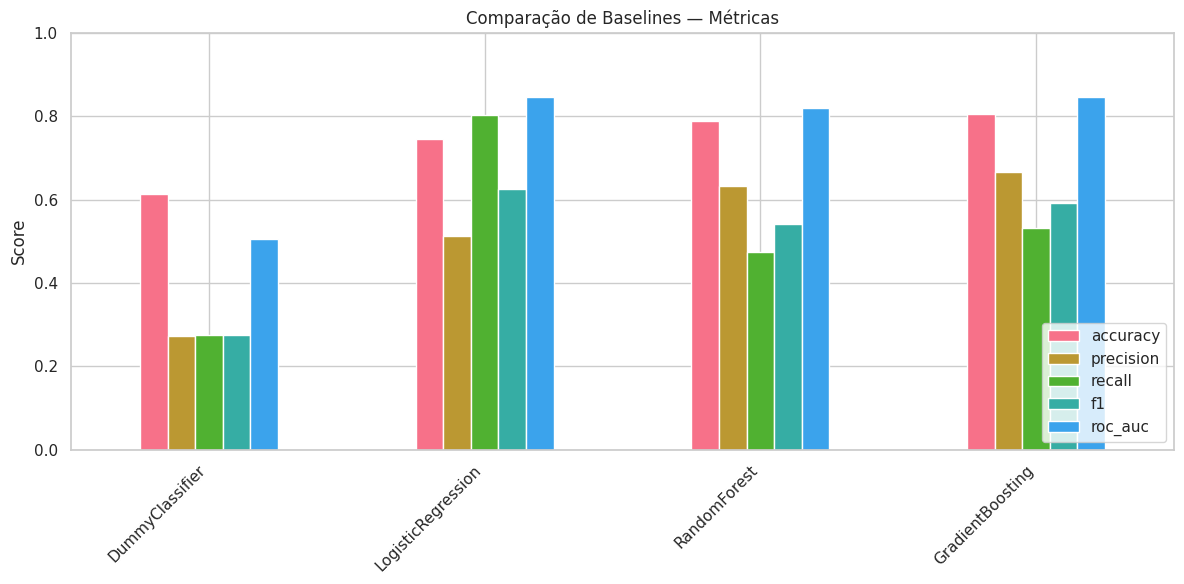

In [11]:
# Visualizar resultados dos baselines
fig, ax = plt.subplots(figsize=(12, 6))
results_df.plot(kind='bar', ax=ax)
ax.set_title('Comparação de Baselines — Métricas')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('../docs/baselines_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusões da EDA

### Insights Principais:
1. **Desbalanceamento**: ~26.5% de churn — necessário usar técnicas de balanceamento
2. **Tenure é forte preditor**: Clientes novos (< 12 meses) têm maior taxa de churn
3. **Contrato mensal = alto risco**: Clientes sem compromisso de longo prazo saem mais
4. **Fiber optic + sem suporte**: Combinação de alto risco de churn
5. **Electronic check**: Método de pagamento associado a maior churn

### Data Readiness: ✅
- Dataset limpo (poucos NaN)
- Features relevantes para o problema
- Volume adequado (~7000 registros)
- Pronto para modelagem com pré-processamento adequado